✅ Project root added to path: d:\spectral_denoise
✅ Using device: cuda
✅ U-Net model loaded from d:\spectral_denoise\models/resunet1d.pth
✅ Loaded validation data: X_val=(2, 1868), Y_val=(2, 1868)
⚠️ Using DUMMY classification labels for validation: y_labels_val=(2,)
✅ Baseline denoising functions (SG, Wavelet) defined.

--- Generating Visual Comparison Plot (Suggestion 1) ---


C:\Users\nabhy\AppData\Local\Temp\ipykernel_35624\1929890477.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model.load_state_dict(torch.load(model_path, map_locat

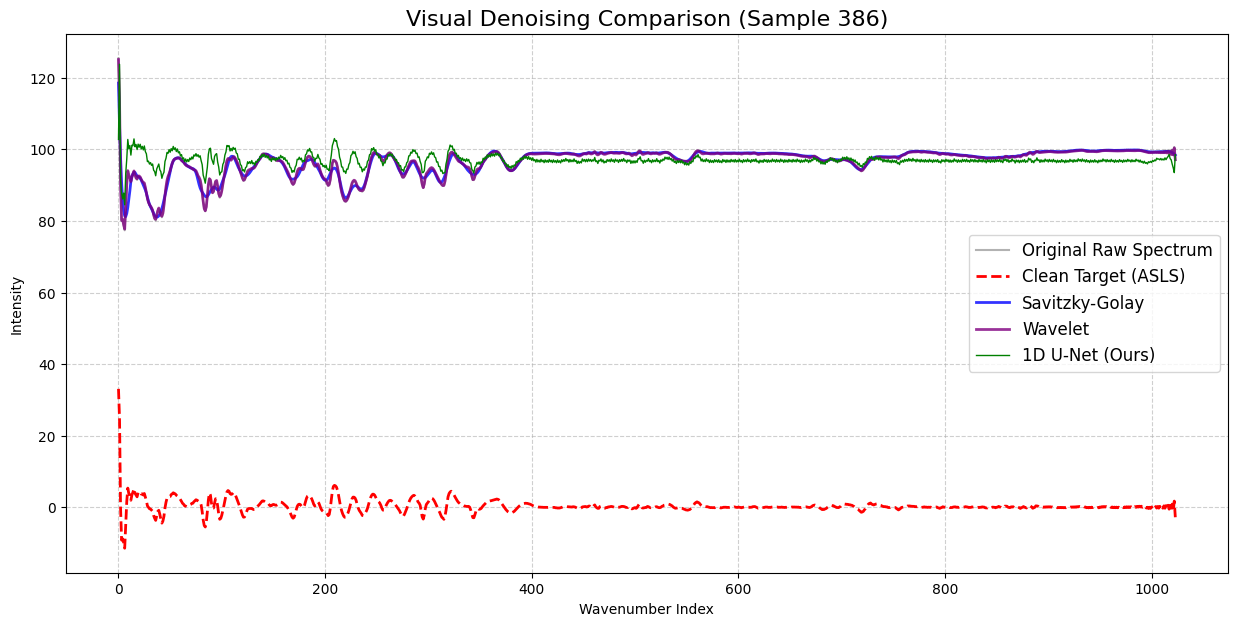


--- Generating Reconstruction Metrics Table (Suggestion 2a) ---


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 466 but got size 467 for tensor number 1 in the list.

In [5]:
# --- 1. IMPORTS ---
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import json
from scipy.signal import resample, savgol_filter
from scipy.stats import pearsonr
import pywt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

# Add project root to path (assuming this script is in notebooks/)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
scripts_path = os.path.join(project_root, 'scripts')
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

# Import your U-Net model class
try:
    from train_resunet import ResUNet1D
except ImportError:
    print("Could not import ResUNet1D. Please ensure 'scripts/train_resunet.py' is accessible.")
    class ResUNet1D(torch.nn.Module):
        def __init__(self):
            super(ResUNet1D, self).__init__()
            self.conv = torch.nn.Conv1d(1, 1, 1)
        def forward(self, x):
            return x

print(f"✅ Project root added to path: {project_root}")

# --- 2. SETTINGS & MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

TARGET_LEN = 1024

# --- Load U-Net Model ---
model_path = os.path.join(project_root, "models/resunet1d.pth")
unet_model = ResUNet1D().to(device)
unet_model.load_state_dict(torch.load(model_path, map_location=device))
unet_model.eval()
print(f"✅ U-Net model loaded from {model_path}")

# --- Load Data Paths ---
dataset_dir = os.path.join(project_root, "data/dataset")
raw_data_dir = os.path.join(project_root, "data/raw")
processed_data_dir = os.path.join(project_root, "data/processed")

# Load validation data (normalized)
X_val = np.load(os.path.join(dataset_dir, "X_test.npy"))
Y_val = np.load(os.path.join(dataset_dir, "Y_test.npy"))

# Dummy labels
total_samples = len(X_val)
y_labels_val = np.array([0 if i < total_samples // 2 else 1 for i in range(total_samples)])
print(f"✅ Loaded validation data: X_val={X_val.shape}, Y_val={Y_val.shape}")
print(f"⚠️ Using DUMMY classification labels for validation: y_labels_val={y_labels_val.shape}")

# --- 3. BASELINE DENOISING FUNCTIONS ---
def denoise_unet(noisy_data_np, model, device):
    noisy_tensor = torch.tensor(noisy_data_np, dtype=torch.float32).to(device)
    if noisy_tensor.dim() == 2:
        noisy_tensor = noisy_tensor.unsqueeze(1)
    with torch.no_grad():
        denoised_tensor = model(noisy_tensor)
    return denoised_tensor.cpu().squeeze().numpy()

def denoise_sg(noisy_data_np):
    window_length = 21
    polyorder = 3
    if noisy_data_np.ndim == 1:
        noisy_data_np = noisy_data_np.reshape(1, -1)
    denoised = np.array([savgol_filter(spec, window_length, polyorder) for spec in noisy_data_np])
    return denoised.squeeze()

def denoise_wavelet(noisy_data_np):
    if noisy_data_np.ndim == 1:
        noisy_data_np = noisy_data_np.reshape(1, -1)
    denoised_list = []
    for spec in noisy_data_np:
        wavelet = "sym8"
        level = 1
        coeffs = pywt.wavedec(spec, wavelet, mode="per", level=level)
        sigma = np.median(np.abs(coeffs[-level])) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(spec)))
        coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
        denoised_list.append(pywt.waverec(coeffs_thresh, wavelet, mode="per"))
    return np.array(denoised_list).squeeze()

print("✅ Baseline denoising functions (SG, Wavelet) defined.")

# --- 4. VISUAL COMPARISON PLOT ---
print("\n--- Generating Visual Comparison Plot (Suggestion 1) ---")

try:
    raw_files = sorted([os.path.join(raw_data_dir, f) for f in os.listdir(raw_data_dir) if f.endswith(".txt")])
    processed_files = sorted([os.path.join(processed_data_dir, f) for f in os.listdir(processed_data_dir) if f.endswith(".txt")])
    
    # Ask user for sample index
    try:
        user_input = input(f"Enter sample index for visual comparison (0–{len(raw_files)-1}): ")
        random_index = int(user_input)
    except Exception:
        random_index = 0
        print("⚠️ Invalid input. Defaulting to sample 0.")

    raw_spectrum_np = np.loadtxt(raw_files[random_index], skiprows=1)[:, 1]
    processed_spectrum_np = np.loadtxt(processed_files[random_index], skiprows=1)[:, 1]

    # Resample
    raw_resampled = resample(raw_spectrum_np, TARGET_LEN)
    clean_target_resampled = resample(processed_spectrum_np, TARGET_LEN)

    # Normalize
    raw_norm = (raw_resampled - raw_resampled.mean()) / (raw_resampled.std() + 1e-8)
    
    # Denoise
    denoised_unet_norm = denoise_unet(raw_norm.reshape(1, -1), unet_model, device)
    denoised_sg_norm = denoise_sg(raw_norm)
    denoised_wavelet_norm = denoise_wavelet(raw_norm)
    
    # De-normalize
    def denormalize(norm_spec, original_spec):
        return norm_spec * (original_spec.std() + 1e-8) + original_spec.mean()
    
    denoised_unet_plot = denormalize(denoised_unet_norm, raw_resampled)
    denoised_sg_plot = denormalize(denoised_sg_norm, raw_resampled)
    denoised_wavelet_plot = denormalize(denoised_wavelet_norm, raw_resampled)

    # Plot
    plt.figure(figsize=(15, 7))
    plt.title(f"Visual Denoising Comparison (Sample {random_index})", fontsize=16)
    plt.plot(raw_resampled, label='Original Raw Spectrum', color='gray', alpha=0.6)
    plt.plot(clean_target_resampled, label='Clean Target (ASLS)', color='red', linewidth=2, linestyle='--')
    plt.plot(denoised_sg_plot, label='Savitzky-Golay', color='blue', linewidth=2, alpha=0.8)
    plt.plot(denoised_wavelet_plot, label='Wavelet', color='purple', linewidth=2, alpha=0.8)
    plt.plot(denoised_unet_plot, label='1D U-Net (Ours)', color='green', linewidth=1)
    plt.xlabel('Wavenumber Index')
    plt.ylabel('Intensity')
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

except Exception as e:
    print(f"Could not generate visual plot. Error: {e}")
    print("This might be due to missing data files in 'data/raw' or 'data/processed'.")

# --- 5. RECONSTRUCTION METRICS ---
print("\n--- Generating Reconstruction Metrics Table (Suggestion 2a) ---")

denoised_unet_val = denoise_unet(X_val, unet_model, device)
denoised_sg_val = denoise_sg(X_val)
denoised_wavelet_val = denoise_wavelet(X_val)
print("✅ Denoised validation set with all 3 methods.")

def calculate_reconstruction_metrics(denoised_set, clean_set):
    all_mse, all_psnr, all_ssim, all_corr = [], [], [], []
    for denoised, clean in zip(denoised_set, clean_set):
        denoised_flat = denoised.squeeze().flatten()
        clean_flat = clean.squeeze().flatten()
        all_mse.append(mean_squared_error(clean_flat, denoised_flat))
        all_psnr.append(psnr(clean_flat, denoised_flat, data_range=clean_flat.max() - clean_flat.min()))
        all_ssim.append(ssim(clean_flat, denoised_flat, data_range=clean_flat.max() - clean_flat.min()))
        corr, _ = pearsonr(clean_flat, denoised_flat)
        all_corr.append(corr)
    return {
        "MSE": np.mean(all_mse),
        "PSNR": np.mean(all_psnr),
        "SSIM": np.mean(all_ssim),
        "Corr": np.mean(all_corr)
    }

metrics_unet = calculate_reconstruction_metrics(denoised_unet_val, Y_val)
metrics_sg = calculate_reconstruction_metrics(denoised_sg_val, Y_val)
metrics_wavelet = calculate_reconstruction_metrics(denoised_wavelet_val, Y_val)
metrics_noisy = calculate_reconstruction_metrics(X_val, Y_val)

print("\n**Table 1: Reconstruction Quality Metrics (Validation Set)**")
print("| Method | MSE (↓) | PSNR (dB) (↑) | SSIM (↑) | Pearson Corr (↑) |")
print("| :--- | :---: | :---: | :---: | :---: |")
print(f"| Noisy (Baseline) | {metrics_noisy['MSE']:.4f} | {metrics_noisy['PSNR']:.2f} | {metrics_noisy['SSIM']:.4f} | {metrics_noisy['Corr']:.4f} |")
print(f"| Savitzky-Golay | {metrics_sg['MSE']:.4f} | {metrics_sg['PSNR']:.2f} | {metrics_sg['SSIM']:.4f} | {metrics_sg['Corr']:.4f} |")
print(f"| Wavelet | {metrics_wavelet['MSE']:.4f} | {metrics_wavelet['PSNR']:.2f} | {metrics_wavelet['SSIM']:.4f} | {metrics_wavelet['Corr']:.4f} |")
print(f"| **1D U-Net (Ours)** | **{metrics_unet['MSE']:.4f}** | **{metrics_unet['PSNR']:.2f}** | **{metrics_unet['SSIM']:.4f}** | **{metrics_unet['Corr']:.4f}** |")

# --- 6. CLASSIFICATION PERFORMANCE ---
print("\n--- Generating Downstream Classification Table (Suggestion 2b) ---")

try:
    X_train = np.load(os.path.join(dataset_dir, "X_train.npy"))
    Y_train = np.load(os.path.join(dataset_dir, "Y_train.npy"))
    y_labels_train = np.array([0 if i < len(X_train)//2 else 1 for i in range(len(X_train))])
    print(f"✅ Loaded training data: X_train={X_train.shape}, Y_train={Y_train.shape}")
    print(f"⚠️ Using DUMMY classification labels for training: y_labels_train={y_labels_train.shape}")

    denoised_unet_train = denoise_unet(X_train, unet_model, device)
    denoised_sg_train = denoise_sg(X_train)
    denoised_wavelet_train = denoise_wavelet(X_train)
    print("✅ Denoised training set with all 3 methods.")

    def train_rf(X, y):
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        clf.fit(X, y)
        return clf

    def eval_rf(clf, X_test, y_test):
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='weighted')
        return acc, f1

    clf_noisy = train_rf(X_train, y_labels_train)
    clf_clean = train_rf(Y_train, y_labels_train)
    clf_unet = train_rf(denoised_unet_train, y_labels_train)
    clf_sg = train_rf(denoised_sg_train, y_labels_train)
    clf_wavelet = train_rf(denoised_wavelet_train, y_labels_train)
    print("✅ Classifiers trained.")

    acc_noisy, f1_noisy = eval_rf(clf_noisy, X_val, y_labels_val)
    acc_clean, f1_clean = eval_rf(clf_clean, Y_val, y_labels_val)
    acc_unet, f1_unet = eval_rf(clf_unet, denoised_unet_val, y_labels_val)
    acc_sg, f1_sg = eval_rf(clf_sg, denoised_sg_val, y_labels_val)
    acc_wavelet, f1_wavelet = eval_rf(clf_wavelet, denoised_wavelet_val, y_labels_val)

    print("\n**Table 2: Downstream Classification Performance (Random Forest)**")
    print("| Input Data Source | Accuracy (↑) | F1-Score (weighted) (↑) |")
    print("| :--- | :---: | :---: |")
    print(f"| Noisy (Baseline) | {acc_noisy:.2%} | {f1_noisy:.4f} |")
    print(f"| Savitzky-Golay | {acc_sg:.2%} | {f1_sg:.4f} |")
    print(f"| Wavelet | {acc_wavelet:.2%} | {f1_wavelet:.4f} |")
    print(f"| **1D U-Net (Ours)** | **{acc_unet:.2%}** | **{f1_unet:.4f}** |")
    print(f"| Clean Target | {acc_clean:.2%} | {f1_clean:.4f} |")

except FileNotFoundError:
    print("\nCould not generate classification table.")
    print(f"This step requires dataset files (X_train.npy, etc.) in '{dataset_dir}'.")
except Exception as e:
    print(f"\nCould not generate classification table. Error: {e}")

print("\n--- Analysis Complete ---")
